# Assignment 1 — Social Data Analysis and Visualization

## Temporal, Spatial, and Statistical Analysis of San Francisco Crime Data (2003–2025)

**Course:** Social Data Analysis and Visualization  
**Date:** March 2, 2026  

### Group Members
- Victor Jonathan Hald (s183710)
- Julie Kruse Lange (s214340)
- Katherina Kronborg (s214352)

# Introduction

This report presents a structured analysis of San Francisco crime data from 2003–2025.  
We investigate temporal trends, spatial concentration, conditional district profiles, distributional properties, and weekly rhythmic similarities across selected Personal Focus Crimes.

The goal is to apply analytical and visualization techniques from Weeks 1–4 and interpret the resulting patterns critically and objectively.

All figures are generated directly from the merged dataset constructed in Week 2.

# Assignment 1.1 — Temporal Overview


## Objective

We examine long-term temporal trends (2003–2025) for our selected Personal Focus Crimes.

For each crime type, we compute and plot the total number of incidents per year.

The goal is to identify structural trends, discontinuities, or major events influencing crime patterns (e.g., policy changes or COVID-19 effects).

First, we import the packages we will use.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from datetime import datetime, time

Then we load the data.

In [2]:
data = pd.read_csv("../Data/2003_2026.csv")

We make sure that the date format is correct, and add a column for years to make it easier to work with.

In [3]:
data["Incident Datetime"] = pd.to_datetime(data["Incident Datetime"])
data["Year"] = data["Incident Datetime"].dt.year

In [4]:
# Defining Personal Focus Crimes
focus_crimes = [
    "Robbery",
    "Assault",
    "Motor Vehicle Theft",
    "Burglary",
    "Larceny Theft",
    "Drug Offense",
    "Arson",
    "Vandalism"
]

# Filtering dataset
focus_data = data[data["Incident Category"].isin(focus_crimes)]
focus_data.head(2)

,Incident Category,Incident Datetime,Incident Day of Week,Incident Code,Incident Description,Police District,Longitude,Latitude,Year
0,Robbery,2004-11-22 17:50:00,Monday,3074,"ROBBERY, BODILY FORCE",Ingleside,-122.420084,37.708311,2004
1,Motor Vehicle Theft,2005-10-18 20:00:00,Tuesday,7021,STOLEN AUTOMOBILE,Park,-120.500000,90.000000,2005


In [5]:
# Grouping by Year and Incident Category
yearly_counts = (
    focus_data
    .groupby(["Year", "Incident Category"])
    .size()
    .reset_index(name="Count")
)


In [6]:
# Pivot table for plotting
pivot_table = yearly_counts.pivot(
    index="Year",
    columns="Incident Category",
    values="Count"
)

# Restricting to required year range
pivot_table = pivot_table.loc[2003:2025]


We plot it in a single plot to make it easy to see the changes.

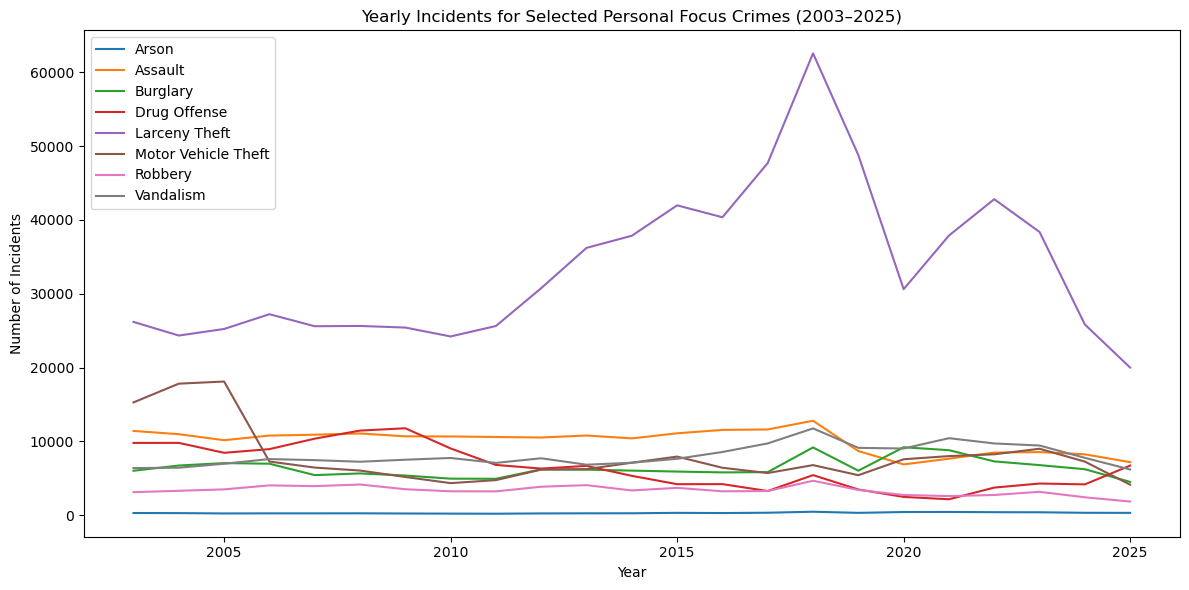

In [7]:
plt.figure(figsize=(12, 6))

for crime in pivot_table.columns:
    plt.plot(pivot_table.index, pivot_table[crime], label=crime)

plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.title("Yearly Incidents for Selected Personal Focus Crimes (2003–2025)")
plt.legend()
plt.tight_layout()
plt.show()


## Interpretation of Temporal Patterns

### Notable Feature 1: Sharp increase and subsequent decline in Larceny Theft (2013–2020)

The data shows a marked increase in Larceny Theft beginning around 2013, peaking at approximately 62,000 incidents in 2018, followed by a sharp decline in 2020 to roughly half that level. This is the most pronounced fluctuation among the selected crime types.

The increase likely reflects the broader rise in urban property crime during the mid-to-late 2010s, particularly theft from vehicles. The abrupt drop in 2020 coincides with the COVID-19 pandemic. Reduced tourism, mobility, and commuting likely reduced opportunities for theft. The scale of the decline suggests that routine activity patterns strongly influence property crime levels.

---

### Notable Feature 2: Gradual long-term decline in Drug Offenses

Drug Offenses exhibit a sustained downward trend from the mid-2000s to the early 2020s, declining from roughly 10,000–12,000 annual incidents to substantially lower levels after 2018. Unlike property crimes, this pattern appears gradual and structural.

This trend likely reflects changes in policing priorities, legal reforms, or enforcement intensity rather than shifts in underlying drug use. Because drug offenses are enforcement-driven, recorded incidents depend heavily on police activity. Reduced proactive enforcement or policy shifts toward decriminalization can therefore lower recorded incidents without necessarily reducing drug prevalence.


# Assignment 1.2 — Crime Profiles by Police District

## Objective

We quantify how crime types are distributed across police districts using conditional probabilities.

For each district and crime type, we compute:

$$
r(\text{crime}, \text{district}) 
= \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}
$$

Values:

- \> 1 → Over-represented
- < 1 → Under-represented
- = 1 → Matches city-wide distribution

In [8]:
# Total number of focus crime incidents
total_incidents = len(focus_data)

# City-wide probability of each crime
city_crime_counts = focus_data["Incident Category"].value_counts()

P_crime = city_crime_counts / total_incidents

P_crime

Incident Category
Larceny Theft          0.441016
Assault                0.132430
Vandalism              0.105988
Motor Vehicle Theft    0.103576
Drug Offense           0.085067
Burglary               0.084029
Robbery                0.044003
Arson                  0.003891
Name: count, dtype: float64

In [9]:
# Counting crimes per district and category
district_crime_counts = (
    focus_data
    .groupby(["Police District", "Incident Category"])
    .size()
    .reset_index(name="Count")
)

# Total incidents per district
district_totals = (
    focus_data
    .groupby("Police District")
    .size()
    .reset_index(name="District Total")
)

# Merging totals back
district_crime_counts = district_crime_counts.merge(
    district_totals,
    on="Police District"
)

# Computing conditional probability P(crime | district)
district_crime_counts["P_crime_given_district"] = (
    district_crime_counts["Count"] /
    district_crime_counts["District Total"]
)


In [10]:
# Mapping city-wide P(crime) into dataframe
district_crime_counts["P_crime_city"] = district_crime_counts["Incident Category"].map(P_crime)

# Computing ratio
district_crime_counts["r_value"] = (
    district_crime_counts["P_crime_given_district"] /
    district_crime_counts["P_crime_city"]
)


In [11]:
# Pivot table: districts x crimes
r_pivot = district_crime_counts.pivot(
    index="Police District",
    columns="Incident Category",
    values="r_value"
)

# REMOVE "Out of SF"
r_pivot = r_pivot.drop(index="Out of SF")

r_pivot

Incident Category,Arson,Assault,Burglary,Drug Offense,Larceny Theft,Motor Vehicle Theft,Robbery,Vandalism
Police District,,,,,,,,
Bayview,2.430587,1.336427,1.082580,0.811459,0.662832,1.637601,1.268323,1.281439
Central,0.749133,0.768119,0.981137,0.290175,1.328027,0.604444,0.831235,0.975309
Ingleside,1.222777,1.176525,1.119958,0.475624,0.698479,1.943240,1.365792,1.278006
Mission,1.039249,1.252112,0.911957,1.272115,0.835442,1.093163,1.303497,1.002631
Northern,0.800540,0.782351,1.118178,0.593342,1.206812,0.799862,0.812197,0.924974
Park,0.712259,0.769968,1.396417,0.803259,0.993638,1.291310,0.650358,1.028556
Richmond,0.859530,0.637189,1.209608,0.274622,1.185923,1.186746,0.582226,1.091822
Southern,0.771515,0.986183,0.827925,1.054320,1.160348,0.578370,0.950021,0.884053
Taraval,0.975730,0.850674,1.278736,0.334890,0.964392,1.480830,0.790126,1.265719


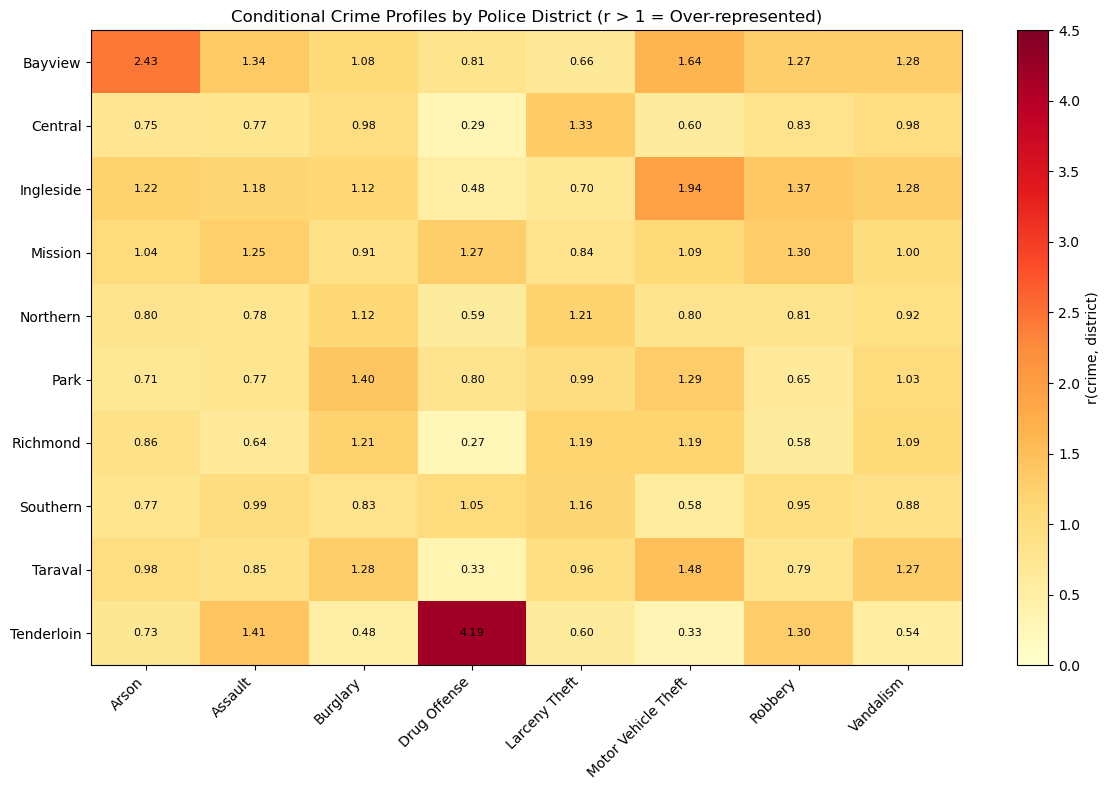

In [12]:
plt.figure(figsize=(12, 8))

# Plot heatmap
im = plt.imshow(
    r_pivot,
    aspect='auto',
    cmap="YlOrRd",
    vmin=0,
    vmax=4.5
)

# Add colorbar
plt.colorbar(im, label="r(crime, district)")

# Axis ticks
plt.xticks(
    ticks=np.arange(len(r_pivot.columns)),
    labels=r_pivot.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    ticks=np.arange(len(r_pivot.index)),
    labels=r_pivot.index
)

# Add numeric values inside cells
for i in range(r_pivot.shape[0]):
    for j in range(r_pivot.shape[1]):
        value = r_pivot.iloc[i, j]
        plt.text(
            j, i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )

plt.title("Conditional Crime Profiles by Police District (r > 1 = Over-represented)")
plt.tight_layout()
plt.show()

## District Profile Interpretation  

### Selected District: Tenderloin  

Tenderloin stands out due to a highly asymmetric crime profile. Drug Offenses are extremely over-represented (r = 4.19), meaning the share of drug offenses in this district is more than four times the city-wide average. Assault (r = 1.41) and Robbery (r = 1.30) are also over-represented.

In contrast, several property crimes are under-represented relative to the city average, including Burglary (r = 0.48), Larceny Theft (r = 0.60), Motor Vehicle Theft (r = 0.33), and Vandalism (r = 0.54). Arson is also below the city average (r = 0.73).  

This pattern indicates a concentration of public-order and interpersonal offenses rather than property-based crimes.

### Possible Explanations  

Tenderloin is a dense, centrally located neighborhood characterized by high levels of street activity and visible drug markets. The extreme over-representation of drug offenses likely reflects both underlying drug activity and concentrated police enforcement. Because drug offenses are enforcement-driven, higher police presence can substantially increase recorded incidents.  

The under-representation of burglary and vehicle theft may reflect limited residential space, lower vehicle ownership, and fewer high-value private targets relative to other districts. The district’s land use patterns, concentration of social services, and demographic composition likely contribute to its distinctive crime profile.

# Assignment 1.3 — Visualizing Distributions

## Part A — Jitter Plot of Incident Times

### Objective

We examine the recording precision of incident times by creating a jitter plot for one crime type during a single hour interval.

Horizontal axis: time within the hour  
Vertical axis: artificial jitter for visualization

In [13]:
# Date interval
start_date = pd.to_datetime('2018-03-01').date()
end_date   = pd.to_datetime('2018-09-01').date()

# Hour interval (23:00–23:59)
start_time = datetime.strptime('23:00', '%H:%M').time()
end_time   = datetime.strptime('23:59:59', '%H:%M:%S').time()

In [14]:
# Filter to burglary
data_burglary = data[data["Incident Category"] == "Burglary"]

# Filter date range
data_burglary = data_burglary[
    (data_burglary["Incident Datetime"].dt.date >= start_date) &
    (data_burglary["Incident Datetime"].dt.date <= end_date)
]

# Filter hour window
data_burglary = data_burglary[
    (data_burglary["Incident Datetime"].dt.time >= start_time) &
    (data_burglary["Incident Datetime"].dt.time <= end_time)
]

In [15]:
np.random.seed(42)

data_burglary["Jitter"] = np.random.uniform(
    low=-0.1,
    high=0.1,
    size=len(data_burglary)
)

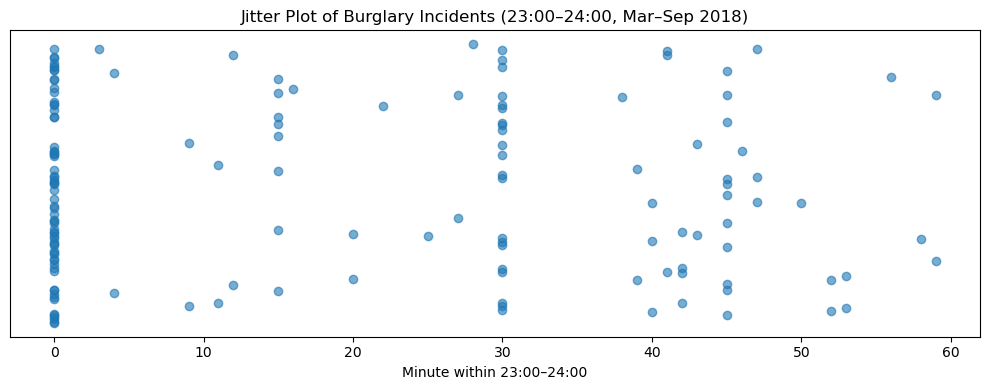

In [16]:
plt.figure(figsize=(10, 4))

plt.scatter(
    data_burglary["Incident Datetime"].dt.minute,
    data_burglary["Jitter"],
    alpha=0.6
)

plt.xlabel("Minute within 23:00–24:00")
plt.yticks([])
plt.title("Jitter Plot of Burglary Incidents (23:00–24:00, Mar–Sep 2018)")
plt.tight_layout()
plt.show()

## Interpretation

The jitter plot shows clear clustering at specific minutes, most notably at 00 minutes (23:00) and around 30 minutes (23:30). Additional smaller clusters appear at regular intervals (e.g., 15 and 45 minutes), while relatively fewer incidents are recorded at arbitrary minute values.

This pattern indicates that incident times are not recorded with fully continuous minute-level precision. Instead, many reports appear to be rounded to salient reference points such as the top or half of the hour.

The clustering at 23:00 is particularly pronounced, suggesting that when the exact time of occurrence is uncertain, incidents may default to the start of the hour. This implies limited temporal precision in the dataset and reflects reporting practices rather than true underlying crime timing patterns.

Overall, the plot suggests that recorded incident times are influenced by administrative rounding or estimation, meaning the dataset does not always represent exact occurrence times.


## Part B — Probability Plot of Latitude Distribution

### Objective

We compare the latitude distribution of two crime types to a normal reference distribution using QQ plots.

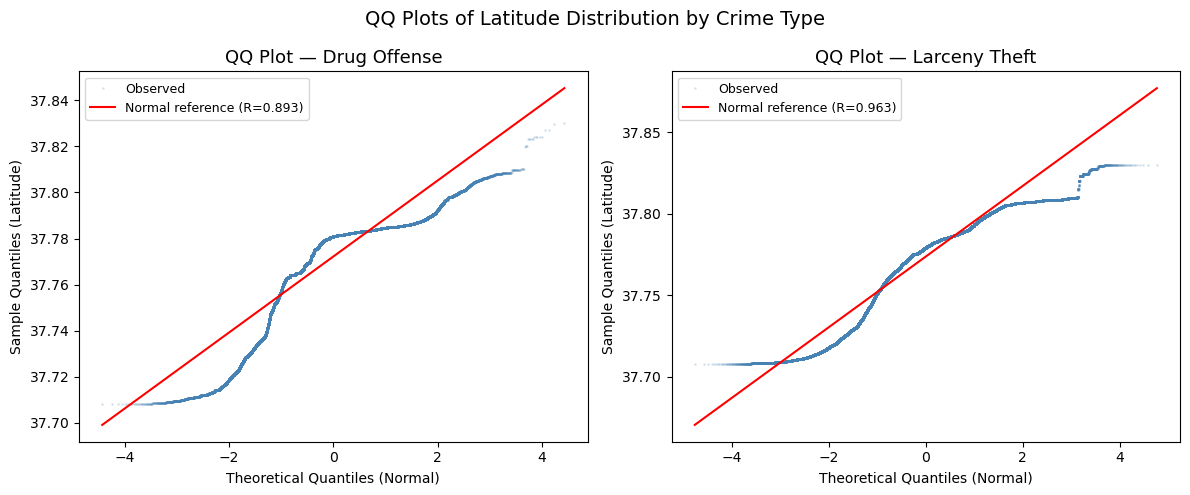

Drug Offense: n = 148,454   latitude range [37.7082, 37.8301]
Larceny Theft: n = 744,095   latitude range [37.7078, 37.8300]


In [17]:
# We select two crime types with contrasting profiles
crime1 = "Drug Offense"
crime2 = "Larceny Theft"

# Filter and clean latitude data — remove sentinel values (e.g., lat = 90.0)
lat1 = focus_data[
    (focus_data["Incident Category"] == crime1) &
    (focus_data["Latitude"] < 90)
]["Latitude"].dropna()

lat2 = focus_data[
    (focus_data["Incident Category"] == crime2) &
    (focus_data["Latitude"] < 90)
]["Latitude"].dropna()

# Create side-by-side QQ plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, lat_data, crime in zip(axes, [lat1, lat2], [crime1, crime2]):
    (osm, osr), (slope, intercept, r) = stats.probplot(lat_data, dist="norm", plot=None)
    ax.plot(osm, osr, '.', alpha=0.15, markersize=2, color="steelblue", label="Observed")
    ax.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5, label=f"Normal reference (R={r:.3f})")
    ax.set_title(f"QQ Plot — {crime}", fontsize=13)
    ax.set_xlabel("Theoretical Quantiles (Normal)")
    ax.set_ylabel("Sample Quantiles (Latitude)")
    ax.legend(fontsize=9)

plt.suptitle("QQ Plots of Latitude Distribution by Crime Type", fontsize=14)
plt.tight_layout()
plt.show()

print(f"{crime1}: n = {len(lat1):,}   latitude range [{lat1.min():.4f}, {lat1.max():.4f}]")
print(f"{crime2}: n = {len(lat2):,}   latitude range [{lat2.min():.4f}, {lat2.max():.4f}]")



## Interpretation

**Reference distribution:** Normal distribution. If points lie exactly on the red line, the latitude distribution is perfectly normal.

### Drug Offense

Drug Offense incidents are strongly concentrated in the Tenderloin district (r = 4.19 from Assignment 1.2), a small area in central SF. The QQ plot shows a pronounced **S-shaped deviation**, reflecting that a large fraction of incidents cluster around one latitude band (~37.78°N). The tails deviate from the normal reference line, indicating a heavy-concentration, non-normal distribution with a prominent central spike rather than a smooth bell curve.

### Larceny Theft

Larceny Theft is distributed more evenly across the city (over-represented in Central, Northern, and Southern districts). Its QQ plot tracks the reference line more closely in the central quantiles, but there is some deviation in the extreme tails — reflecting geographic constraints (SF is bounded by the Bay to the north and east, and by hills to the west and south).

### Key Takeaway

Neither crime type is expected to follow a normal latitude distribution. Drug Offense departs more strongly due to extreme spatial concentration in a single district, while Larceny Theft departs more subtly, reflecting the city's geographic shape. These deviations from normality confirm that latitude alone is insufficient to describe crime geography — spatial clustering and physical boundaries drive the non-normality observed.


## Part C — Time-of-Day Distributions

### Objective

We compare the time-of-day distribution across all Personal Focus Crimes.

<div style="color:red;">

### Expected Output

- Side-by-side boxplots (or violin/raincloud)
- X-axis: Crime types
- Y-axis: Time of day (0–24)
- Proper labeling

</div>

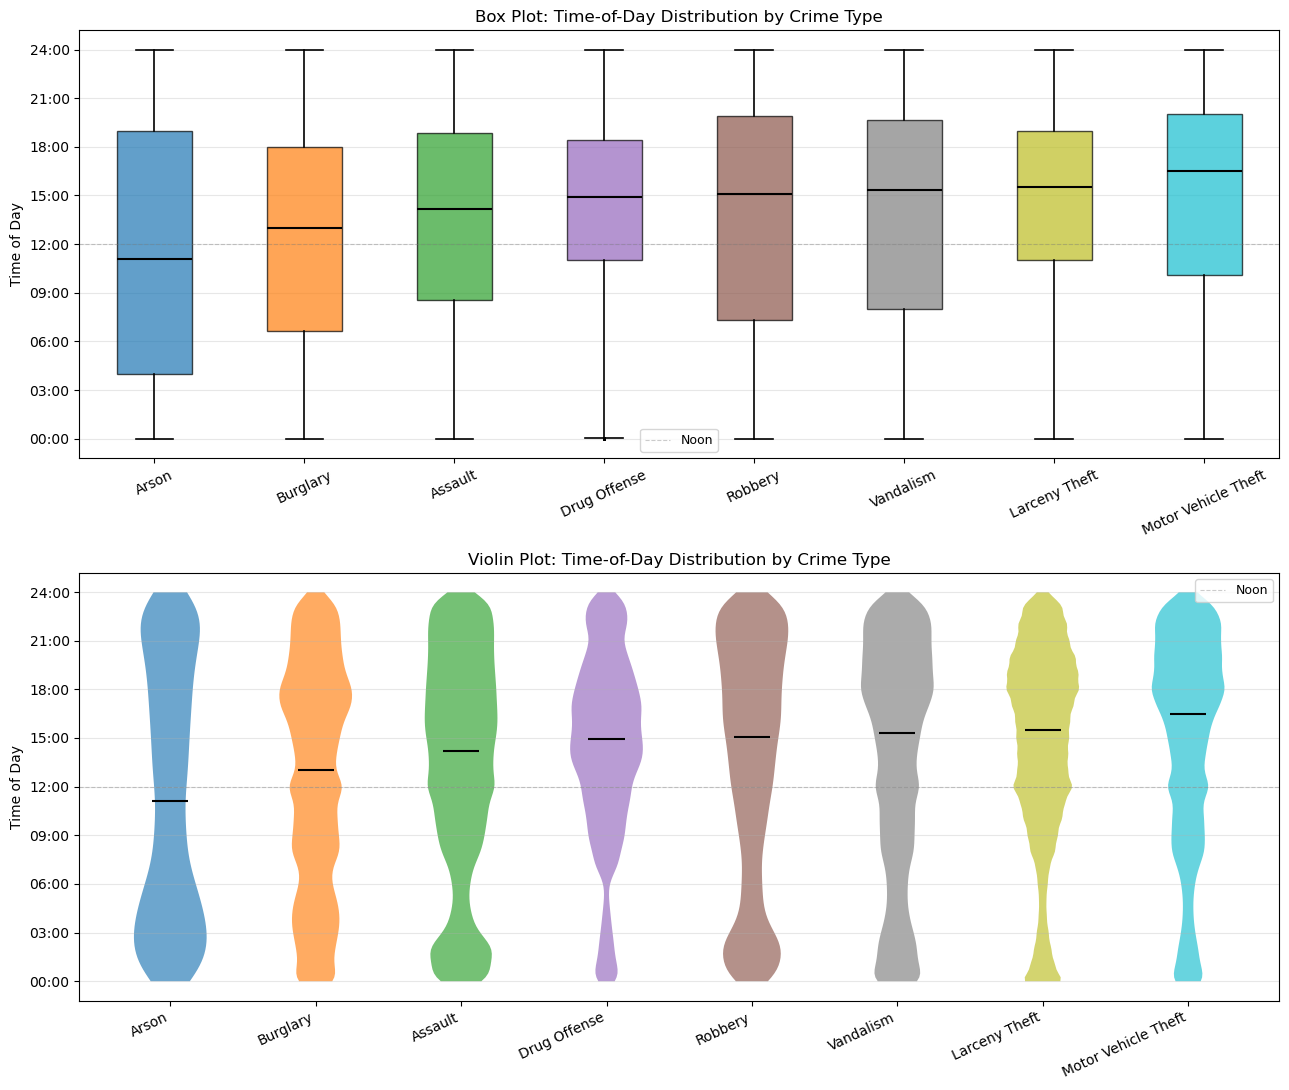

In [18]:

# Extract time of day as decimal hours (0.0 = midnight, 23.99 = just before midnight)
time_data = focus_data.copy()
time_data["TimeOfDay"] = (
    time_data["Incident Datetime"].dt.hour +
    time_data["Incident Datetime"].dt.minute / 60
)

# Order crimes by median time of day (earliest to latest)
crime_order = (
    time_data.groupby("Incident Category")["TimeOfDay"]
    .median()
    .sort_values()
    .index.tolist()
)

# Build per-crime data lists
data_lists = [
    time_data[time_data["Incident Category"] == c]["TimeOfDay"].dropna().values
    for c in crime_order
]

colors = plt.cm.tab10(np.linspace(0, 1, len(crime_order)))
yticks      = range(0, 25, 3)
yticklabels = [f"{h:02d}:00" for h in yticks]

fig, axes = plt.subplots(2, 1, figsize=(13, 11))

# ── Box plot ──────────────────────────────────────────────────────────────────
ax = axes[0]
bp = ax.boxplot(
    data_lists, labels=crime_order, vert=True, patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='.', markersize=1, alpha=0.2)
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Time of Day")
ax.set_title("Box Plot: Time-of-Day Distribution by Crime Type")
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)
ax.axhline(y=12, color='gray', linestyle='--', alpha=0.4, linewidth=0.8, label="Noon")
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)

# ── Violin plot ───────────────────────────────────────────────────────────────
ax = axes[1]
vp = ax.violinplot(
    data_lists,
    positions=range(1, len(crime_order) + 1),
    showmedians=True,
    showextrema=False
)
for body, color in zip(vp['bodies'], colors):
    body.set_facecolor(color)
    body.set_alpha(0.65)
vp['cmedians'].set_color('black')
vp['cmedians'].set_linewidth(1.5)

ax.set_xticks(range(1, len(crime_order) + 1))
ax.set_xticklabels(crime_order, rotation=25, ha='right')
ax.set_ylabel("Time of Day")
ax.set_title("Violin Plot: Time-of-Day Distribution by Crime Type")
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)
ax.axhline(y=12, color='gray', linestyle='--', alpha=0.4, linewidth=0.8, label="Noon")
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()



## Interpretation

### Crimes that peak at night

**Assault**, **Robbery**, **Drug Offense**, **Vandalism**, and **Arson** all show medians in the evening or late-night hours (roughly 20:00–23:00). This is consistent with patterns driven by alcohol consumption, reduced surveillance, and street activity that intensifies after dark. Assault and Robbery in particular are interpersonal crimes that concentrate in social settings such as bars and nightlife venues, which are most active late in the evening.

### Crimes that occur during business hours

**Larceny Theft** has the earliest median and the strongest daytime concentration. This reflects its primary forms — shoplifting, pickpocketing, and theft from vehicles — which require the presence of people in commercial areas. **Motor Vehicle Theft** is comparatively spread across the day, though it also shows an afternoon-to-evening lean. **Burglary** sits closer to midday, consistent with residential burglaries occurring while occupants are away at work.

### The midnight wrap-around problem

The time axis is linear (0–24). Any crime with a distribution centered near midnight — such as Assault or Robbery — has its incidents split across two numeric extremes: values just below 24 and values just above 0. The box plot therefore computes a median and IQR from a range that spans almost the entire axis, even though the true distribution is tightly concentrated around midnight. The median is dragged toward mid-afternoon rather than late night, and the whiskers expand to cover most of the 24-hour range, making the box appear far wider than the true spread. The plot gives the false impression of uniform all-day activity.

A correct fix would use a **circular/angular representation** (e.g., converting hours to angles on a 24-hour clock) so that 23:59 and 00:01 are treated as adjacent rather than opposite extremes. Alternatively, the time axis can be shifted (e.g., starting at 06:00) so that midnight falls near the centre.

### Why violin plots are preferred here

The box plot only communicates five summary statistics (min, Q1, median, Q3, max). The violin plot reveals the full **density shape**, which is critical here:

- Crimes with a single sharp peak (e.g., Larceny Theft clustering around business hours) appear as a narrow waist at that hour.
- Crimes with multiple hotspots during the day appear as **bimodal violins** — a shape the box plot cannot express at all.
- The width of the violin at each hour is proportional to how many incidents fall there, making it immediately clear where activity concentrates rather than just where the middle 50% sits.

Overall, the violin plots reveal substantially more about the temporal rhythm of each crime type and should be preferred over box plots for this type of circular or multimodal time-of-day data.


# Assignment 1.4 — Spatial Power Law

<span style="color:red;">Draws from: Week 4, Exercise 2.2</span>

## Objective

We test whether crime incidents follow a spatial power-law distribution.

We divide San Francisco into ~100m × 100m grid cells and analyze incident concentration.

<div style="color:red;">

### Steps

1. Create spatial grid (100m resolution)
2. Count incidents per grid cell
3. Compute N(k): number of cells with k incidents
4. Plot (k+1) vs N(k) — linear axes
5. Plot (k+1) vs N(k) — log-log axes
6. Assess power-law behavior

</div>

<div style="color:red;">

### CODE CELLS

1. CODE CELL — Grid + Counts
2. CODE CELL — Linear Plot
3. CODE CELL — Log-Log Plot

</div>

<div style="color:blue;">

## Interpretation

If the log-log plot appears approximately linear:
- The distribution may follow a power law.

If highly skewed:
- Crime is spatially concentrated in hotspots.

Implication:
- The “average block” may not be meaningful.
- A small number of cells may dominate total crime counts.

</div>

# Assignment 1.5 — Regression and Correlation

<span style="color:red;">Draws from: Week 4, Exercises 3.1, 3.2, 3.3</span>

## Objective

We analyze weekly rhythms across crime types by:

1. Computing 168-hour weekly incident vectors
2. Creating pairwise scatterplot matrix
3. Fitting regression lines using closed-form equations
4. Computing and displaying R² values

<div style="color:red;">

### Expected Output

- Scatterplot matrix
- Each panel:
    - Points (168 hours)
    - Regression line
    - R² displayed
    - Clear crime labels

</div>

<div style="color:red;">

### CODE CELLS

1. CODE CELL — Weekly aggregation
2. CODE CELL — Regression implementation (closed form)
3. CODE CELL — Scatterplot matrix

</div>

<div style="color:blue;">

## Interpretation

### Most Correlated Pair
- Identify pair
- Provide R²
- Why might they share weekly rhythm?

### Least Correlated Pair
- Identify pair
- Provide R²
- Why are they dissimilar?

Does this match intuition? Explain.

</div>

# Contributions

Victor Jonathan Hald:
- <span style="color:blue;">Description</span>

Julie Kruse Lange:
- <span style="color:blue;">Description</span>

Katherina Kronborg:
- <span style="color:blue;">Assignment 1.1, 1.2, and 1.3 (Part A)</span>

All members contributed equally to discussion, interpretation, and final review.